# Author
Liang Yu



# Part 1: Evaluate the Pretrained Model on Sunny Test Images
In this section, you will load the pretrained model and the dataset. You will then prepare the model and dataset for evaluation.

In [4]:
import torch
from dataset import camvidLoader
import numpy as np

# Set device to 'cuda' for GPU usage or 'cpu' for CPU
device = 'cuda'  # Can be set to "cuda" if you have a GPU

# Load the pretrained U-Net model
unet = torch.load('camvid_sunny_model.pt', map_location=torch.device(device))

# Set the path to your dataset
data_root = '../CamVid/sunny'

# Load the test dataset
test_data = camvidLoader(root=data_root, split='test', is_aug=False, img_size=[384, 384], is_pytorch_transform=True)

# Number of classes in the dataset (fixed to 14 for this project)
num_classes = 14

# Class labels dictionary (used for mapping predicted labels to actual class names)
class_labels_dict = {
    "Sky": 0, "Building": 1, "Pole": 2, "Road": 3, "LaneMarking": 4, "SideWalk": 5, 
    "Pavement": 6, "Tree": 7, "SignSymbol": 8, "Fence": 9, "Car_Bus": 10, "Pedestrian": 11, 
    "Bicyclist": 12, "Unlabelled": 13
}

# Task: Implement Evaluation Metric Functions
In this task, you need to implement two evaluation metrics for the model's performance: Global Accuracy and Intersection over Union (IoU). These metrics will be used to assess the quality of the model's predictions.

In [5]:
# Define global accuracy function
def global_accuracy_metric(y_true, y_pred):
 
    # Make sure the input is a tensor
    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)
        
    # Calculate the correctly predicted number of pixels and the total number of pixels
    correct_pixels = torch.sum(y_true == y_pred).float()
    total_pixels = float(torch.numel(y_true))
    
    # Computational accuracy
    accuracy = correct_pixels / total_pixels
    
    return accuracy.item()

# Define IoU metric function
def IoU_metric(y_true, y_pred):
   
    # Make sure the input is a tensor
    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)
    
    
    num_classes = 14
    class_ious = {}
    
    # Calculate the IoU for each category
    for cls in range(num_classes):
        # Creates a binary mask for the current category
        true_mask = (y_true == cls)
        pred_mask = (y_pred == cls)
        
        # Check if the category is present in the real label or prediction
        if torch.sum(true_mask) == 0 and torch.sum(pred_mask) == 0:
            #If the category does not exist in either the real label or the prediction, it is set to NaN
            class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
            class_ious[class_name] = float('nan')
            continue
        
        # Computes intersection and union
        intersection = torch.logical_and(true_mask, pred_mask).sum().float()
        union = torch.logical_or(true_mask, pred_mask).sum().float()
        
        # Compute IoU, handle edge cases (and set to 0)
        if union == 0:
            iou = torch.tensor(0.0)  # 并集为0，IoU为0
        else:
            iou = intersection / union
        
        # Save the IoU of the current category
        class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
        class_ious[class_name] = iou.item()
    
    # Calculate the average IoU (mIoU), using np.nanmean to ignore NaN values
    iou_values = np.array(list(class_ious.values()))
    mean_iou = np.nanmean(iou_values)
    
    return class_ious, mean_iou

# Task: Write Your Testing Loop
Here, you will implement the testing loop where the model makes predictions on the test data and evaluates its performance using the metrics defined earlier.

In [9]:
from torch.utils.data import DataLoader
# Implement your testing loop here
# This is where you will run the model on the test data and compute the evaluation metrics.
def test_model(model, test_dataset, device, batch_size=1):

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
 
    model.eval()
 
    results = []
    
    with torch.no_grad():  #Disable gradient computing to optimize performance
        for images, labels, img_paths in test_loader:
            # Moves data to the specified device
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward propagation to obtain prediction results
            outputs = model(images)
            
            # Gets the most likely category for each pixel (the index corresponding to the maximum probability)
            _, predictions = torch.max(outputs, dim=1)
            
            # Calculate the evaluation metrics for each image
            for i in range(images.size(0)):
                # Get predictions and real labels for the current image
                pred = predictions[i].cpu()
                true = labels[i].cpu()
                
                accuracy = global_accuracy_metric(true, pred)
                
                class_ious, mean_iou = IoU_-metric(true, pred)
                
                results.append({
                    'img_path': img_paths[i],
                    'accuracy': accuracy,
                    'mean_iou': mean_iou,
                    'class_ious': class_ious,
                    'prediction': pred.numpy(),
                    'ground_truth': true.numpy()
                })
                
    return results

test_results = test_model(unet, test_data, device)

print(f"number of Test image: {len(test_results)}")

mean_accuracy = np.mean([result['accuracy'] for result in test_results])
mean_iou_overall = np.mean([result['mean_iou'] for result in test_results])
print(f"\n Performance:")
print(f"mean ACC: {mean_accuracy:.4f}")
print(f" mean IoU (mIoU): {mean_iou_overall:.4f}")

number of Test image: 140

 Performance:
mean ACC: 0.8804
 mean IoU (mIoU): 0.4802


# Task: Calculate Global Image Accuracy and Per-Class Accuracy
In this task, you will compute the global accuracy and per-class accuracy for the entire test dataset. These metrics will help you evaluate the overall performance of the model and how well it handles each class.

In [14]:
# Implement code to calculate global image accuracy and per-class accuracy here
# This step will involve comparing the predictions with the ground truth labels for each image.

def calculate_dataset_metrics(test_results):

    # Calculate global accuracy (average of all images)
    global_accuracy = np.mean([result['accuracy'] for result in test_results])
    
    # Initializes the IoU values stored for each class on all images
    all_class_ious = {class_name: [] for class_name in class_labels_dict.keys()}
    
    # Collects the IoU values for each category on all images
    for result in test_results:
        for class_name, iou in result['class_ious'].items():
            all_class_ious[class_name].append(iou)
    
    # Calculate the average IoU for each category
    class_ious = {}
    for class_name, ious in all_class_ious.items():
        class_ious[class_name] = np.nanmean(ious)
    
    # Calculate the average IoU for all categories
    mean_iou = np.nanmean(list(class_ious.values()))
    
    return global_accuracy, class_ious, mean_iou

test_results = test_model(unet, test_data, device)

global_accuracy, class_ious, mean_iou = calculate_dataset_metrics(test_results)

print(f"Test Performance:")
print(f"Global Accuracy: {global_accuracy:.4f}")
print(f"mean IoU (mIoU): {mean_iou:.4f}")
print("\nper classIoU:")
for class_name, iou in sorted(class_ious.items(), key=lambda x: x[1], reverse=True):
    print(f"{class_name}: {iou:.4f}")

# Analyze IoU differences between classes
max_iou_class = max(class_ious.items(), key=lambda x: x[1] if not np.isnan(x[1]) else float('-inf'))
min_iou_class = min(class_ious.items(), key=lambda x: x[1] if not np.isnan(x[1]) else float('inf'))

print("\n class IoU ana:")
print(f"Highest IoU class: {max_iou_class[0]} ({max_iou_class[1]:.4f})")
print(f"min IoU class: {min_iou_class[0]} ({min_iou_class[1]:.4f})")
print(f"class IoU std: {np.nanstd(list(class_ious.values())):.4f}")

Test Performance:
Global Accuracy: 0.8804
mean IoU (mIoU): 0.4595

per classIoU:
Road: 0.9307
Sky: 0.9091
Building: 0.7460
SideWalk: 0.6687
LaneMarking: 0.5610
Pavement: nan
Car_Bus: 0.6217
Tree: 0.5988
Pedestrian: 0.2603
Bicyclist: 0.2315
Fence: 0.2197
Unlabelled: 0.1323
Pole: 0.0936
SignSymbol: 0.0000

 class IoU ana:
Highest IoU class: Road (0.9307)
min IoU class: SignSymbol (0.0000)
class IoU std: 0.3047


/tmp/ipykernel_3157/860147058.py:20: RuntimeWarning: Mean of empty slice
  class_ious[class_name] = np.nanmean(ious)


# Task: Image Ranking Based on Accuracy Scores
In this task, you will rank the images in the dataset based on their global accuracy and mean IoU scores. You should select a few examples where the model performs exceptionally well and others where it struggles.

ACC RANK（top 5）:
1. Seq05VD_f04110.png - ACC: 0.9578, MEAN IoU: 0.5504
2. 0006R0_f03090.png - ACC: 0.9541, MEAN IoU: 0.4104
3. 0016E5_07971.png - ACC: 0.9518, MEAN IoU: 0.6110
4. Seq05VD_f04080.png - ACC: 0.9470, MEAN IoU: 0.5381
5. 0016E5_08131.png - ACC: 0.9451, MEAN IoU: 0.6600

ACC RANK（last 5）:
136. 0016E5_01920.png - ACC: 0.7996, MEAN IoU: 0.4950
137. 0016E5_08580.png - ACC: 0.7979, MEAN IoU: 0.4895
138. 0016E5_00420.png - ACC: 0.7789, MEAN IoU: 0.3478
139. Seq05VD_f04770.png - ACC: 0.7768, MEAN IoU: 0.3374
140. 0016E5_02310.png - ACC: 0.7556, MEAN IoU: 0.4294

MEAN IoU rank（top 5）:
1. 0016E5_08111.png - MEAN IoU: 0.6892, ACC: 0.9392
2. 0016E5_08109.png - MEAN IoU: 0.6721, ACC: 0.9285
3. 0016E5_08131.png - MEAN IoU: 0.6600, ACC: 0.9451
4. 0016E5_08127.png - MEAN IoU: 0.6589, ACC: 0.9446
5. 0016E5_08125.png - MEAN IoU: 0.6480, ACC: 0.9273

MEAN IoU rank（last 5）:
136. 0006R0_f01350.png - MEAN IoU: 0.3522, ACC: 0.8660
137. 0016E5_00420.png - MEAN IoU: 0.3478, ACC: 0.7789
138. Seq05V

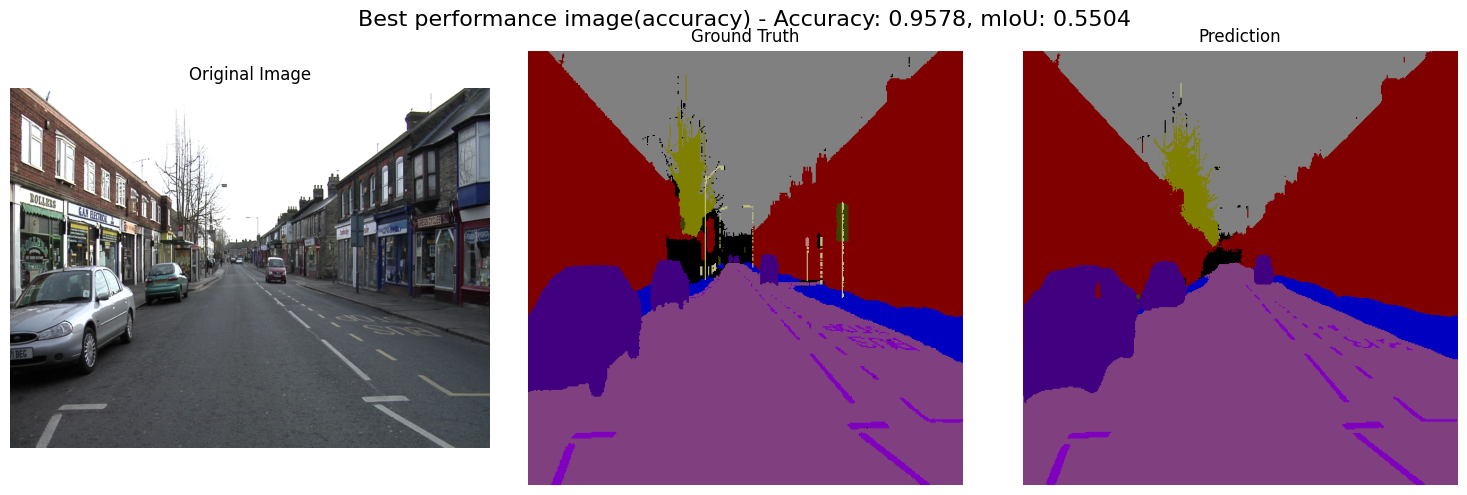

Class IoU values for all 14 categories:
Road: 0.9748
Sky: 0.9704
Building: 0.9282
Car_Bus: 0.9161
SideWalk: 0.7868
LaneMarking: 0.7549
Tree: 0.5568
Unlabelled: 0.1662
Pole: 0.0000
SignSymbol: 0.0000
Pedestrian: 0.0000
Pavement: nan (not present in this image)
Fence: nan (not present in this image)
Bicyclist: nan (not present in this image)

 preformance worst（ACC）:


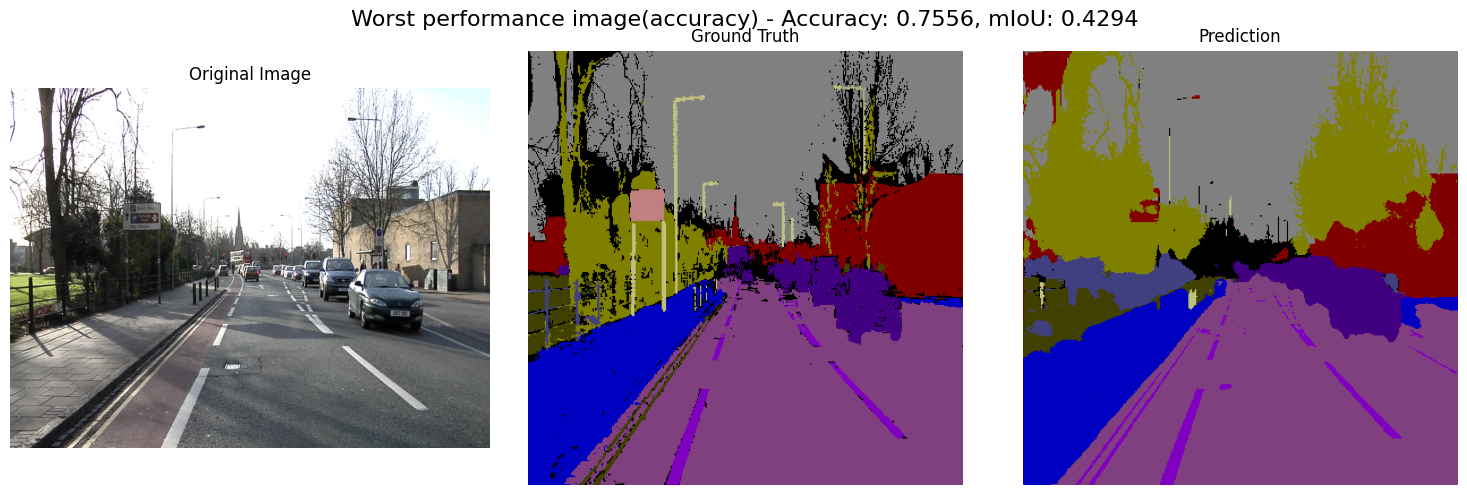

Class IoU values for all 14 categories:
Road: 0.9421
SideWalk: 0.8879
Sky: 0.8302
Car_Bus: 0.7306
LaneMarking: 0.5712
Building: 0.4893
Pedestrian: 0.3288
Tree: 0.2296
Unlabelled: 0.0580
Pole: 0.0462
Fence: 0.0390
SignSymbol: 0.0000
Pavement: nan (not present in this image)
Bicyclist: nan (not present in this image)

 preformance best（IoU）:


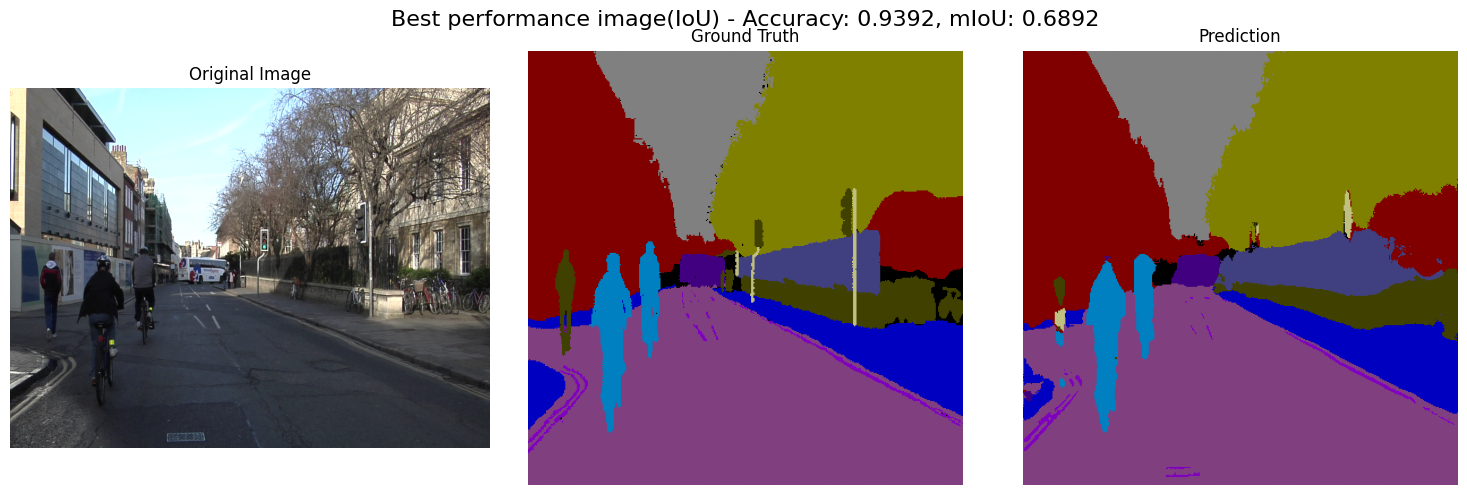

Class IoU values for all 14 categories:
Sky: 0.9595
Road: 0.9559
Tree: 0.9524
Building: 0.9160
SideWalk: 0.8428
Bicyclist: 0.8427
Car_Bus: 0.8293
Fence: 0.6415
Pedestrian: 0.5894
LaneMarking: 0.5011
Pole: 0.1215
Unlabelled: 0.1188
Pavement: nan (not present in this image)
SignSymbol: nan (not present in this image)

 preformance worst（IoU）:


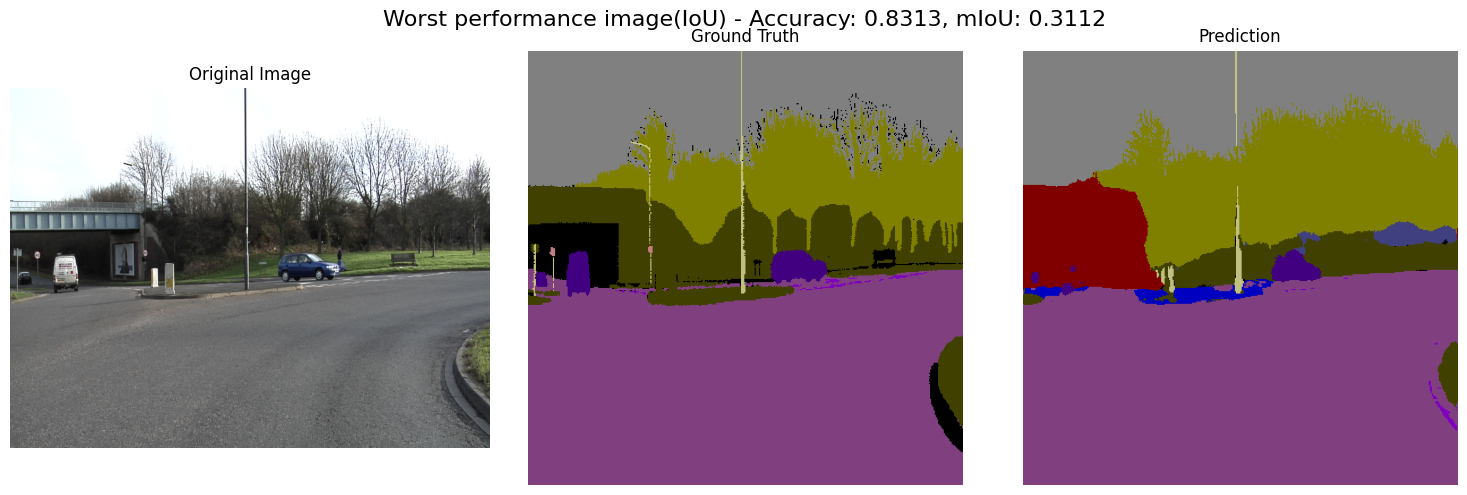

Class IoU values for all 14 categories:
Road: 0.9582
Sky: 0.9127
Tree: 0.6746
Car_Bus: 0.4962
Pole: 0.3406
Pedestrian: 0.3144
LaneMarking: 0.0369
Unlabelled: 0.0011
Building: 0.0000
SideWalk: 0.0000
SignSymbol: 0.0000
Fence: 0.0000
Pavement: nan (not present in this image)
Bicyclist: nan (not present in this image)

class mean IoU rank (include 14 class):
Road: 0.9307
Sky: 0.9091
Building: 0.7460
SideWalk: 0.6687
Car_Bus: 0.6217
Tree: 0.5988
LaneMarking: 0.5610
Pedestrian: 0.2603
Bicyclist: 0.2315
Fence: 0.2197
Unlabelled: 0.1323
Pole: 0.0936
SignSymbol: 0.0000
Pavement: nan (not in test)


In [15]:
# Implement image ranking code here
# Rank images based on global image accuracy and mean IoU scores, and select examples for further analysis.

import os.path as osp
from skimage.io import imread
import matplotlib.pyplot as plt
from dataset import from_label_to_rgb

def rank_and_analyze_images(test_results):

    # Sort by accuracy
    acc_sorted = sorted(test_results, key=lambda x: x['accuracy'], reverse=True)
    
    #Sort by average IoU
    iou_sorted = sorted(test_results, key=lambda x: x['mean_iou'], reverse=True)
    
    # Display accuracy ranking
    print("ACC RANK（top 5）:")
    for i, result in enumerate(acc_sorted[:5]):
        img_name = osp.basename(result['img_path'])
        print(f"{i+1}. {img_name} - ACC: {result['accuracy']:.4f}, MEAN IoU: {result['mean_iou']:.4f}")
    
    print("\nACC RANK（last 5）:")
    for i, result in enumerate(acc_sorted[-5:]):
        img_name = osp.basename(result['img_path'])
        print(f"{len(acc_sorted)-4+i}. {img_name} - ACC: {result['accuracy']:.4f}, MEAN IoU: {result['mean_iou']:.4f}")
    
    # The IoU ranking is displayed
    print("\nMEAN IoU rank（top 5）:")
    for i, result in enumerate(iou_sorted[:5]):
        img_name = osp.basename(result['img_path'])
        print(f"{i+1}. {img_name} - MEAN IoU: {result['mean_iou']:.4f}, ACC: {result['accuracy']:.4f}")
    
    print("\nMEAN IoU rank（last 5）:")
    for i, result in enumerate(iou_sorted[-5:]):
        img_name = osp.basename(result['img_path'])
        print(f"{len(iou_sorted)-4+i}. {img_name} - MEAN IoU: {result['mean_iou']:.4f}, ACC: {result['accuracy']:.4f}")
    
    # Select typical examples of good performance and poor performance for analysis
    best_acc = acc_sorted[0]
    worst_acc = acc_sorted[-1]
    best_iou = iou_sorted[0]
    worst_iou = iou_sorted[-1]
    
    return best_acc, worst_acc, best_iou, worst_iou

# Visualization function to display artwork, real labels, and prediction results
def visualize_results(result, title):

    img_path = result['img_path']
    img = imread(img_path)
    
    gt = result['ground_truth']
    pred = result['prediction']

    gt_rgb = from_label_to_rgb(gt)
    pred_rgb = from_label_to_rgb(pred)

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"{title} - Accuracy: {result['accuracy']:.4f}, mIoU: {result['mean_iou']:.4f}", fontsize=16)
    
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_rgb)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred_rgb)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    print(f"Class IoU values for all 14 categories:")
    class_ious = result['class_ious']
    for cls, iou in sorted(class_ious.items(), key=lambda x: (np.isnan(x[1]), -x[1] if not np.isnan(x[1]) else 0)):
        if np.isnan(iou):
            print(f"{cls}: nan (not present in this image)")
        else:
            print(f"{cls}: {iou:.4f}")

def analyze_segmentation_challenges(test_results):
# Analysis by category IoU
    class_performance = {class_name: [] for class_name in class_labels_dict.keys()}
    
  # Collect performance data for each category - including all categories, even 0 or nan
    for result in test_results:
        for class_name, iou in result['class_ious'].items():
            class_performance[class_name].append((result['img_path'], iou))
    
 # Find the best and worst performing images in each category
    class_best_worst = {}
    for class_name, performances in class_performance.items():
        valid_performances = [(p[0], p[1]) for p in performances if not np.isnan(p[1])]
        if valid_performances: # If the category has a valid value in the test set
            valid_performances.sort(key=lambda x: x[1], reverse=True)
            best = valid_performances[0]
            worst = valid_performances[-1]
            class_best_worst[class_name] = {'best': best, 'worst': worst}
        else:
            class_best_worst[class_name] = {'best': None, 'worst': None}
    
 # Calculate the average IoU for each category - make sure all categories are displayed
    class_avg_iou = {}
    for class_name, performances in class_performance.items():
        valid_ious = [p[1] for p in performances if not np.isnan(p[1])]
        if valid_ious:
            class_avg_iou[class_name] = np.mean(valid_ious)
        else:
            class_avg_iou[class_name] = float('nan') # Set explicitly to nan instead of skipping
    
  # Sort display (put nan last)
    sorted_classes = sorted(
        class_avg_iou.items(), 
        key=lambda x: (np.isnan(x[1]), -x[1] if not np.isnan(x[1]) else 0)
    )
    
    print("\nclass mean IoU rank (include 14 class):")
    for class_name, avg_iou in sorted_classes:
        if np.isnan(avg_iou):
            print(f"{class_name}: nan (not in test)")
        else:
            print(f"{class_name}: {avg_iou:.4f}")
    
    return class_best_worst

# Perform analysis
best_acc, worst_acc, best_iou, worst_iou = rank_and_analyze_images(test_results)

# Visualize the best and worst examples
print("\n preformance best（ACC）:")
visualize_results(best_acc, "Best performance image(accuracy)")

print("\n preformance worst（ACC）:")
visualize_results(worst_acc, "Worst performance image(accuracy)")

print("\n preformance best（IoU）:")
visualize_results(best_iou, "Best performance image(IoU)")

print("\n preformance worst（IoU）:")
visualize_results(worst_iou, "Worst performance image(IoU)")

class_best_worst = analyze_segmentation_challenges(test_results)

